In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
FIT = FitSpectrum()
DP = DP()

ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 29.51 seconds.
Total number of spectra: 99812


In [4]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR
0,39627739380056154,177.002481,-1.922543,0.296782,GALAXY,10.522085,-0.613677
1,39627739380056197,177.003822,-1.903397,0.224113,GALAXY,10.250155,-0.348563
2,39627739380056420,177.013472,-1.972766,0.102005,GALAXY,9.722920,-0.349153
3,39627739380056564,177.019312,-1.965308,0.323187,GALAXY,10.452706,0.941032
4,39627739380056768,177.028143,-1.960056,0.102814,GALAXY,10.143390,0.193251


In [5]:
ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(10)
print('Number of spectra after shrinking:', len(ALL_SPECTRA.targetID))

Number of spectra after shrinking: 9982


In [6]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR
0,39627739380056154,177.002481,-1.922543,0.296782,GALAXY,10.522085,-0.613677
1,39627739380057597,177.061873,-1.931940,0.168429,GALAXY,0.000000,0.000000
2,39627739380058467,177.097982,-1.888290,0.123931,GALAXY,10.402426,1.031611
3,39627739380060759,177.201238,-1.884376,0.094108,GALAXY,11.102370,-5.244847
4,39627739384253386,177.379085,-1.974526,0.266292,GALAXY,10.608374,-2.461456


In [19]:
test_idx = 2
test_id = ALL_SPECTRA.df.iloc[test_idx]["TARGETID"]
print(f'TARGETID: {test_id}')
lam = desi_wavelength / (1+ALL_SPECTRA.df.iloc[test_idx]['Z'])

TARGETID: 39627739380058467


In [20]:
test_df = ALL_SPECTRA.df.iloc[test_idx]
print(test_df)

TARGETID    39627739380058467
RA                 177.097982
DEC                  -1.88829
Z                    0.123931
SPECTYPE               GALAXY
LOGM                10.402426
LOGSFR               1.031611
Name: 2, dtype: object


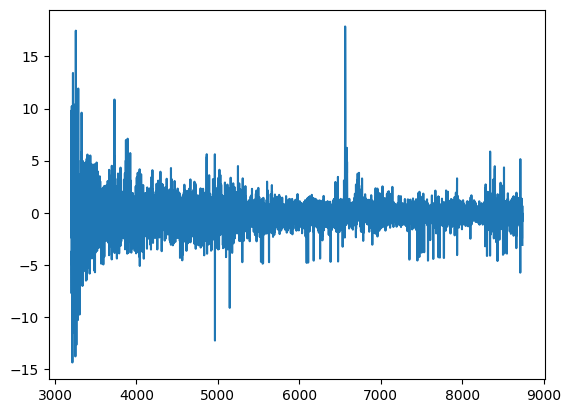

In [21]:
plt.plot(lam, ALL_SPECTRA.flux[test_idx], label='Flux')
plt.show()

TARGETID    39627739380058467
RA                 177.097982
DEC                  -1.88829
Z                    0.123931
SPECTYPE               GALAXY
LOGM                10.402426
LOGSFR               1.031611
Name: 2, dtype: object


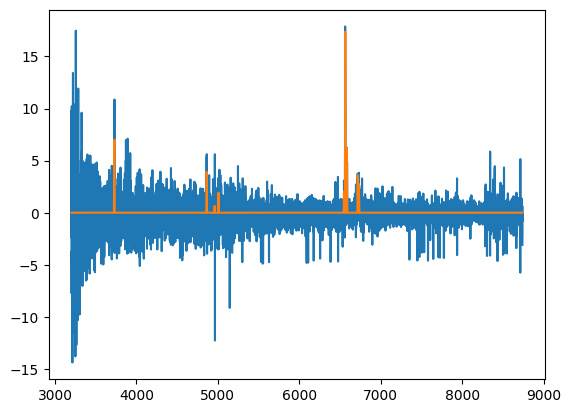

In [22]:
params_1comp, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=False, w_dz=False)
model_1comp = np.sum([
    model_vel(lam, gaussian_parms=params_1comp['gaussian_params'][i]) for i in range(len(params_1comp['gaussian_params']))
], axis=0)


plt.plot(lam, ALL_SPECTRA.flux[test_idx], label='Flux')
plt.plot(lam, model_1comp, label='Model (1 component)')
plt.show()